Подайте последовательно на вход APT сети 8 бинарных векторов

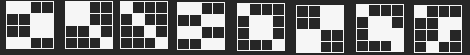

Стуркутра APT-1

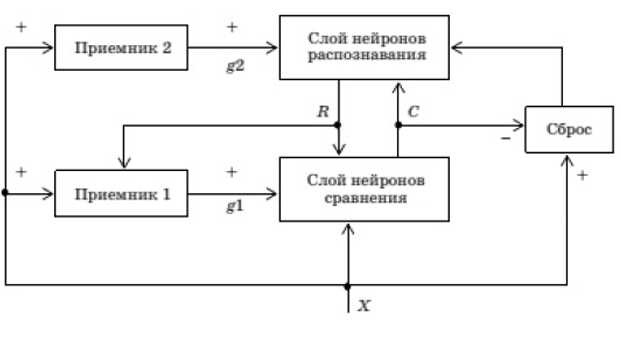

Его аспект:
Проблема пластичности-стабильности - приобретение нового знания нарушения уже существующего

*   Если входной вектор похож на один из ранее запомненных векторов, то запомненный вектор будет изменяться, чтобы стать похожим на входной веткор;
*   Возможен отказ от классификации, если входной вектор не похож ни на один из запомненных векторов. В этой ситуации образуется новый класс.

In [47]:
import numpy as np

In [48]:
def print_image(vector):
    matrix = vector.reshape((4, 4))
    for row in matrix:
        print(" ".join(["██" if val == 1 else "  " for val in row]))
    print("-" * 25)

####Датасет

In [49]:
x1 = np.array([
     1, 1, 0, 0,
     0, 0, 1, 1,
     0, 0, 1, 1,
     1, 1, 0, 0
])

x2 = np.array([
     1, 1, 0, 0,
     1, 1, 0, 0,
     0, 0, 1, 0,
     0, 0, 0, 1
])

x3 = np.array([
     1, 0, 0, 0,
     0, 1, 0, 0,
     0, 0, 1, 0,
     0, 0, 0, 1
])

x4 = np.array([
     1, 1, 0, 0,
     0, 0, 1, 1,
     1, 1, 0, 0,
     0, 0, 1, 1
])

x5 = np.array([
     1, 0, 0, 0,
     0, 1, 1, 0,
     0, 1, 1, 0,
     0, 0, 0, 1
])

x6 = np.array([
     0, 0, 1, 1,
     0, 0, 1, 1,
     1, 1, 0, 0,
     1, 1, 0, 0
])

x7 = np.array([
     1, 0, 0, 0,
     0, 1, 1, 0,
     0, 1, 1, 1,
     0, 0, 0, 1
])

x8 = np.array([
     1, 0, 0, 0,
     0, 0, 1, 1,
     0, 0, 1, 0,
     0, 1, 0, 0
])

X = [x1,x2,x3,x4,x5,x6,x7,x8]

for i in X:
  print_image(i)


██ ██      
      ██ ██
      ██ ██
██ ██      
-------------------------
██ ██      
██ ██      
      ██   
         ██
-------------------------
██         
   ██      
      ██   
         ██
-------------------------
██ ██      
      ██ ██
██ ██      
      ██ ██
-------------------------
██         
   ██ ██   
   ██ ██   
         ██
-------------------------
      ██ ██
      ██ ██
██ ██      
██ ██      
-------------------------
██         
   ██ ██   
   ██ ██ ██
         ██
-------------------------
██         
      ██ ██
      ██   
   ██      
-------------------------


Ниже представлены строчки кода, которые выполнены по примеру жизненного цикла APT



1.   Инициализация

Для начала проводим аналитические вычисления для первого образца

Здесь же, взяты параметры с лекции:


*   S_kr - критерий сходства (чем больше, тем строже сходство образа и кластера для отнесения к последнему);
*   lambda - степень влияния нового входного образа на кратковременную память (обычно lambda = 2)
*   v - коэффициент скорость адаптации




In [50]:
def fun_for_B(lambd, vector):
    return (lambd / (lambd - 1 + np.sum(vector))) * vector

In [51]:
S_kr = 0.7
lambd = 2
v = 0.6

# Инициалазация (1) - певрый кластер
T1 = X[0].copy()          # Шаблон Сверху-Вниз
B1 = fun_for_B(lambd, T1) # Веса Снизу-Вверх

# Массив наших кластеров
T_clusters = [T1] #кластеры
B_clusters = [B1] #Веса

# Список, куда мы запишем финальный ответ: какой образ куда попал
history = [0] # Первый образ автоматически попал в кластер 0
print("Начальный шаблон T1 (содержит 0 и 1):")
print_image(T1)

print("Получившиеся веса B1 (содержат дробные значения):")
print(np.round(B1, 2))
print("-" * 25)


Начальный шаблон T1 (содержит 0 и 1):
██ ██      
      ██ ██
      ██ ██
██ ██      
-------------------------
Получившиеся веса B1 (содержат дробные значения):
[0.22 0.22 0.   0.   0.   0.   0.22 0.22 0.   0.   0.22 0.22 0.22 0.22
 0.   0.  ]
-------------------------


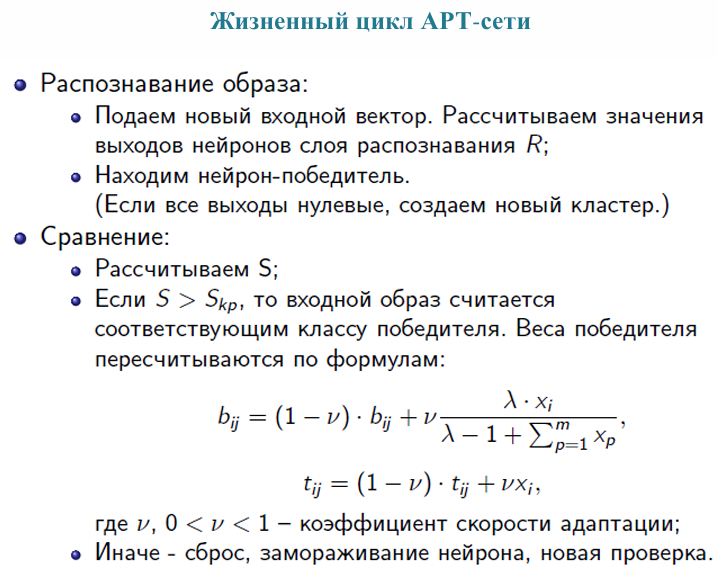

Сравнение из формулы S = N / D, где D - число единиц в векторе с наибольшим числом единиц

#### ЗАМЕЧАНИЕ: изначально g1 = 1, а сигналы pj = 0, поэтому исходно вектор С совпадает с Х

In [52]:
def fun_APT(Y_i, T):
  return 1 if Y_i >= T else 0

In [53]:
def run_APT(new_vector, B, T, S_kr, lambd, v):
    # Слой распознавания
    Y = np.dot(B, new_vector)

    # Слой сравнения
    # из-за v-дробного значения, в массиве T-дробные числа - округляем
    P = (T >= 0.5).astype(int)        # эталон "сверху-вниз" в бинарном виде
    ad = new_vector * P     # битовое И входа и эталона
    norm_intersection = np.sum(ad)
    norm_new = np.sum(new_vector)
    S = norm_intersection / norm_new

    print(f"  Y = {round(Y, 3)}, сходство S = {round(S, 3)} (надо >= {S_kr})")

    # блок сброса
    if S >= S_kr:
        B_new = (1 - v) * B + v * fun_for_B(lambd, new_vector)
        T_new = (1 - v) * T + v * new_vector
        return B_new, T_new, "Резонанс"
    else:
        return B, T, "Сброс"

Прогонка для оставшихся образов, начиная со второго

In [54]:
for i in range(1, len(X)):
    current_vector = X[i]
    print(f"\nПодаем Образ #{i + 1}:")
    print_image(current_vector)

    cluster_found = False

    for c_idx in range(len(T_clusters)):

        B_mod, T_mod, result = run_APT(current_vector, B_clusters[c_idx], T_clusters[c_idx], S_kr, lambd, v)

        if result == "Резонанс":
            print(f"Образ подошел к Кластеру {c_idx}! Веса обновлены.")
            # Обновляем измененные веса в списках
            B_clusters[c_idx] = B_mod
            T_clusters[c_idx] = T_mod

            history.append(c_idx) # Запоминаем, что образ ушел в этот кластер
            cluster_found = True
            break

        else:
            print(f"Кластер {c_idx} отверг этот образ. Идем проверять следующий...")

    if not cluster_found:
        print("Ни один кластер не подошел. Создаем новый кластер!")

        # те же самые действия, как при инициализации
        new_T = current_vector.copy()
        new_B = fun_for_B(lambd, new_T)
        T_clusters.append(new_T)
        B_clusters.append(new_B)

        # Запоминаем индекс нового кластера (он равен последнему индексу в списке)
        new_cluster_idx = len(T_clusters) - 1
        history.append(new_cluster_idx)


Подаем Образ #2:
██ ██      
██ ██      
      ██   
         ██
-------------------------
  Y = 0.667, сходство S = 0.5 (надо >= 0.7)
Кластер 0 отверг этот образ. Идем проверять следующий...
Ни один кластер не подошел. Создаем новый кластер!

Подаем Образ #3:
██         
   ██      
      ██   
         ██
-------------------------
  Y = 0.444, сходство S = 0.5 (надо >= 0.7)
Кластер 0 отверг этот образ. Идем проверять следующий...
  Y = 1.143, сходство S = 1.0 (надо >= 0.7)
Образ подошел к Кластеру 1! Веса обновлены.

Подаем Образ #4:
██ ██      
      ██ ██
██ ██      
      ██ ██
-------------------------
  Y = 0.889, сходство S = 0.5 (надо >= 0.7)
Кластер 0 отверг этот образ. Идем проверять следующий...
  Y = 0.823, сходство S = 0.25 (надо >= 0.7)
Кластер 1 отверг этот образ. Идем проверять следующий...
Ни один кластер не подошел. Создаем новый кластер!

Подаем Образ #5:
██         
   ██ ██   
   ██ ██   
         ██
-------------------------
  Y = 0.667, сходство S = 0.5 (надо >

Тестирование

In [55]:
print("Исходные образы:")
for i, x in enumerate(X):
    print(f"Образ {i+1}:")
    print_image(x)

print(" Кластеризация")
print("="*20)
for img_idx, cls_idx in enumerate(history):
    print(f"Образ #{img_idx + 1} -> попал в кластер {cls_idx}")

Исходные образы:
Образ 1:
██ ██      
      ██ ██
      ██ ██
██ ██      
-------------------------
Образ 2:
██ ██      
██ ██      
      ██   
         ██
-------------------------
Образ 3:
██         
   ██      
      ██   
         ██
-------------------------
Образ 4:
██ ██      
      ██ ██
██ ██      
      ██ ██
-------------------------
Образ 5:
██         
   ██ ██   
   ██ ██   
         ██
-------------------------
Образ 6:
      ██ ██
      ██ ██
██ ██      
██ ██      
-------------------------
Образ 7:
██         
   ██ ██   
   ██ ██ ██
         ██
-------------------------
Образ 8:
██         
      ██ ██
      ██   
   ██      
-------------------------
 Кластеризация
Образ #1 -> попал в кластер 0
Образ #2 -> попал в кластер 1
Образ #3 -> попал в кластер 1
Образ #4 -> попал в кластер 2
Образ #5 -> попал в кластер 3
Образ #6 -> попал в кластер 4
Образ #7 -> попал в кластер 3
Образ #8 -> попал в кластер 0
